In [3]:
import sys
print(sys.executable)

d:\python\8.ml-project\venv\python.exe


In [5]:
%pip install scikit-learn catboost xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.1 MB/s eta 0:01:31
   ---------------------------------------- 0.8/101.7 MB 1.0 MB/s eta 0:01:39
   ---------------------------------------- 1.0/101.7 MB 960.6 kB/s eta 0:01:45
    --------------------------------------- 1.3/101.7 MB 1.0 MB/s eta 0:01:40
    --------------------------------------- 1.3/101.7 MB 1.0 MB/s eta 0:01:40
    --------------------------------------- 1.6/101.7 MB 983.7 kB/s eta 0:01:42
    --------------------------------------- 1.8/101.7 MB 1.0 MB/s eta 0:01:39
    --------------------

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv('data/stud.csv')

In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
X = df.drop(columns=['math score'],axis=0)

In [13]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [14]:
y = df['math score']

In [15]:
# create column transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="str").columns
cat_features = X.select_dtypes(include="str").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("Onehotencoder",oh_transformer, cat_features),
        ("standardscaler", numeric_transformer, num_features)
    ]
)

In [16]:
X = preprocessor.fit_transform(X)

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

In [ ]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [26]:
# Define different regression models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}


# Function to evaluate the model
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)

    return mae, rmse, r2_square


# Create empty lists
model_list = []
r2_list = []


# Train and evaluate each model
for i in range(len(list(models))):

    # Get model
    model = list(models.values())[i]

    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)


    # Evaluate Train dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(
        y_train,
        y_train_pred
    )


    # Evaluate Test dataset
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(
        y_test,
        y_test_pred
    )


    # Print model name
    print(list(models.keys())[i])


    # Store model name
    model_list.append(list(models.keys())[i])


    # Store Test R2 Score
    r2_list.append(model_test_r2)


    # Print Training Set Performance
    print("Model performance for Training set")

    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))

    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))

    print("- R2 Score: {:.4f}".format(model_train_r2))


    print("----------------------------------")


    # Print Test Set Performance
    print("Model performance for Test set")

    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))

    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))

    print("- R2 Score: {:.4f}".format(model_test_r2))


    print("=" * 35)

    print("\n")




Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7077
- Mean Absolute Error: 4.5167
- R2 Score: 0.8555
-----------------------

In [27]:
# Create DataFrame of model performance
pd.DataFrame(
    list(zip(model_list, r2_list)),
    columns=['Model Name', 'R2_Score']
).sort_values(
    by=["R2_Score"],
    ascending=False
)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
7,CatBoosting Regressor,0.851632
5,Random Forest Regressor,0.850861
8,AdaBoost Regressor,0.847601
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree Regressor,0.755793


In [28]:
# we go with linear regresssion
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print("Accuracy of model is %.2f" %score)

Accuracy of model is 88.04


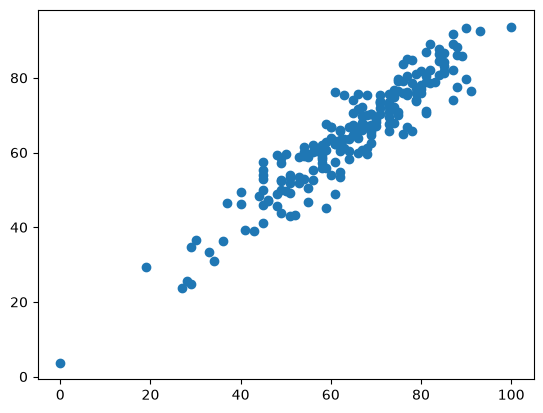

In [29]:
plt.scatter(y_test,y_pred);

<Axes: xlabel='math score'>

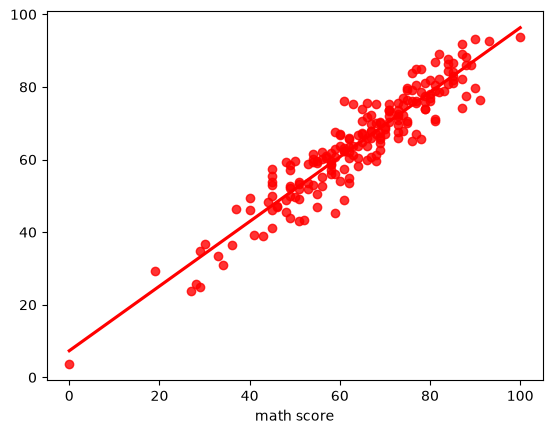

In [30]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

In [31]:
# diff btwn actual and predicted values
pred_df = pd.DataFrame({'Actual value':y_test,'predicted value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual value,predicted value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
